# Task 2: Season Classification


## 1. Introduction

This notebook addresses **Task 2: Season Classification** for Assignment 2 by predicting the catalogue season assigned to a fashion product from its RGB image. The task is formulated as **a four-class image classification problem with the labels Spring, Summer, Fall, and Winter**.

Three neural-network approaches are developed and trained from scratch using TensorFlow/Keras:

- **Shallow MLP (Baseline):** A fully connected network with one 256-unit hidden layer operating on flattened image pixels.
- **Deeper MLP:** A fully connected network with hidden layers of 256, 128, and 64 units, using dropout to reduce overfitting.
- **Convolutional Neural Network (CNN):** A spatial model that learns local image patterns through convolutional layers. The CNN family includes three declared architecture/scheduling configurations.

Performance is assessed using:

- **Accuracy:** The proportion of correctly classified images.
- **Macro-F1:** The primary selection metric, giving equal weight to the F1 scores of classes present in the evaluation partition.
- **Per-class classification reports and confusion matrices:** Evidence of which labels are recognized reliably and which are confused.
- **Learning curves:** Training and validation loss, accuracy, and macro-F1 used to examine convergence and overfitting.
- **Calibration metrics:** Confidence reliability of the selected model, assessed after selection using separate validation groups.

Catalogue seasons may overlap visually and reflect merchandising decisions. Predictions describe dataset labels; they do not establish whether a garment is suitable for particular weather.

The workflow covers metadata inspection, preprocessing, model development, comparative evaluation, selection, and export for prediction. All candidates use the same frozen group-isolated data partitions. The internal test has prior development exposure, which remains a limitation after retraining. Numerical findings and the final model judgment must be completed from the new executed results; no winner is assumed in advance.


## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.

In [18]:
from pathlib import Path
import sys, json
from concurrent.futures import ThreadPoolExecutor
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import task_frame, IMAGE_SIZE, NORMALISATION_PATH, SEED, select_tensorflow_device
DEVICE = select_tensorflow_device()
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS, FIGURES = (ROOT / 'models', ROOT / 'results', ROOT / 'figures')
for directory in (OUTPUT, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target

TensorFlow 2.20.0: /GPU:0


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.

In [19]:
metadata_by_target = {'season': task_frame('season')}
frame = metadata_by_target['season']
print('season', frame.shape)
display(frame.head())

season (38591, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.

### 4.1. Class Distribution & Balancing Strategy

Inspect only the training labels when deciding how to handle imbalance. We retain the original distribution rather than upsampling; macro-F1 makes minority-class errors visible in selection. All candidates use ordinary cross-entropy, so their results remain comparable.

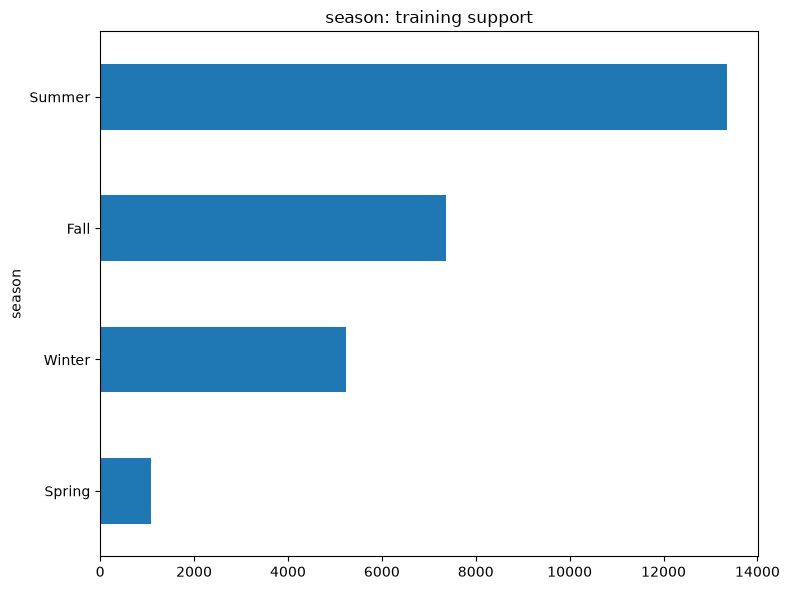

In [20]:
train_rows = metadata_by_target['season'].loc[metadata_by_target['season']['split'].eq('train')]
counts = train_rows['season'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'season'}: training support")
plt.tight_layout()
plt.show()

### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking. Do not use the internal test to select candidates.

In [21]:
def validation_views(frame):
    selection_ids, rest_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
                                   .split(frame, groups=frame.group_key))
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1)
                              .split(rest, groups=rest.group_key))
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]

In [22]:
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(metadata_by_target['season'].loc[metadata_by_target['season']['split'].eq('validation')])
frames['season'] = dict(train=metadata_by_target['season'].loc[metadata_by_target['season']['split'].eq('train')], selection=selection, calibration=calibration, policy=policy)
groups = [set(frame.group_key) for frame in frames['season'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1:]))
labels_by_target['season'] = sorted(frames['season']['train']['season'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['season'].items()}, name='season'))

train          27038
selection       2964
calibration     1445
policy          1429
Name: season, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.

In [23]:
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""
    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size
        def read(path):
            with Image.open(path) as image:
                return np.asarray(image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)).copy()
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)

### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.

In [24]:
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['season']
loaders['season'] = {name: CachedBatches(frames['season'][name], 'season', labels, normalisation, training=name == 'train', batch_size=BATCH_SIZE) for name in ['train', 'selection']}

## 5. Model Development & Evaluation

This section develops three neural-network families trained from scratch on the supplied fashion images. Moving from flattened pixels to deeper dense layers and then spatial convolutions lets us examine how architecture affects performance under the same evaluation protocol.

**Models included:**

- **5.1. Shallow MLP (Baseline):** Establishes the performance of one hidden layer on flattened RGB input.
- **5.2. Deeper MLP:** Tests whether additional dense layers improve the learned representation and generalization.
- **5.3. Convolutional Neural Network (CNN):** Learns spatial features and compares the declared convolutional configurations and learning-rate schedules.

Each model subsection shows its architecture, compilation, and training code. All candidates use the same image size, normalization, batch size, training/selection groups, Adam optimizer, and maximum epoch budget. Training-only horizontal flips and dropout provide regularization. Early stopping restores the epoch with the highest selection macro-F1; scheduled CNNs additionally reduce the learning rate when that metric stalls.

The following subsections compare the restored models, plot learning curves, and evaluate the selected model. Model selection prioritizes **validation macro-F1**, then accuracy, then parameter count. Calibration and review thresholds use separate validation groups. The internal test is evaluated after selection and must not be used to choose an architecture.


### Evaluation Metric: Macro-F1

Accumulate the full-epoch confusion matrix before computing macro-F1. The metric selects the restored best epoch, avoiding averages of per-batch F1.

In [25]:
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(name="matrix", shape=(num_classes, num_classes), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        self.matrix.assign_add(tf.math.confusion_matrix(truth, predictions, self.num_classes,
                                                        weights=weights, dtype=self.dtype))

    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}

### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.

In [26]:
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""
    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}

In [27]:
models = {'season': {}}
histories = {'season': {}}

### 5.1. Shallow MLP (Baseline)


The shallow MLP is the baseline for this experiment. It learns combinations of flattened pixel values through one hidden layer but has no convolutional mechanism for local spatial patterns. Its measured performance provides the reference for the deeper models.


#### 5.1.1. Model Architecture

Flatten the image and use one 256-unit hidden layer as the baseline. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.

In [28]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['season'])), ModelMetadata(name='metadata')])
models['season']['shallow_mlp'] = keras.Sequential(layers, name='shallow_mlp')
models['season']['shallow_mlp'].summary()

Model: "shallow_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,438,468 (36.00 MB)

 Trainable params: 9,438,468 (36.00 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.

In [29]:
model = models['season']['shallow_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['season']))])

#### 5.1.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.

In [30]:
loaders['season']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['season']['shallow_mlp'].fit(loaders['season']['train'], validation_data=loaders['season']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['season']['shallow_mlp'] = pd.DataFrame(fitted.history)
display(histories['season']['shallow_mlp'].tail())

Epoch 1/30
423/423 - 12s - 28ms/step - accuracy: 0.5360 - loss: 2.4482 - macro_f1: 0.4280 - val_accuracy: 0.5992 - val_loss: 0.9290 - val_macro_f1: 0.4880
Epoch 2/30
423/423 - 11s - 25ms/step - accuracy: 0.5772 - loss: 1.4569 - macro_f1: 0.4967 - val_accuracy: 0.6231 - val_loss: 1.1937 - val_macro_f1: 0.5216
Epoch 3/30
423/423 - 11s - 26ms/step - accuracy: 0.5948 - loss: 1.3777 - macro_f1: 0.5136 - val_accuracy: 0.6231 - val_loss: 0.9205 - val_macro_f1: 0.5766
Epoch 4/30
423/423 - 11s - 25ms/step - accuracy: 0.6089 - loss: 1.2560 - macro_f1: 0.5384 - val_accuracy: 0.6339 - val_loss: 1.0153 - val_macro_f1: 0.5527
Epoch 5/30
423/423 - 11s - 26ms/step - accuracy: 0.6125 - loss: 1.1410 - macro_f1: 0.5407 - val_accuracy: 0.6316 - val_loss: 0.8993 - val_macro_f1: 0.5793
Epoch 6/30
423/423 - 12s - 27ms/step - accuracy: 0.6218 - loss: 1.1551 - macro_f1: 0.5614 - val_accuracy: 0.6323 - val_loss: 0.8921 - val_macro_f1: 0.5601
Epoch 7/30
423/423 - 11s - 26ms/step - accuracy: 0.6208 - loss: 1.1828

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
9,0.630631,1.185417,0.566150,0.670378,0.873997,0.604283
10,0.635735,1.002653,0.577897,0.636302,1.463026,0.588838
11,0.632184,1.027687,0.580902,0.635965,1.066135,0.579115
12,0.640506,0.867958,0.591347,0.652159,1.062845,0.586814
13,0.633553,1.311042,0.574699,0.647436,1.602031,0.569178


#### 5.1.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.

season shallow_mlp


selection_accuracy    0.651822
selection_macro_f1    0.613232
dtype: float64

,precision,recall,f1-score,support
Fall,0.616142,0.393216,0.480061,796.000000
Spring,0.830769,0.469565,0.600000,115.000000
Summer,0.620019,0.847278,0.716049,1506.000000
Winter,0.867868,0.528336,0.656818,547.000000
accuracy,0.651822,0.651822,0.651822,0.651822
macro avg,0.733700,0.559599,0.613232,2964.000000
weighted avg,0.672895,0.651822,0.637240,2964.000000


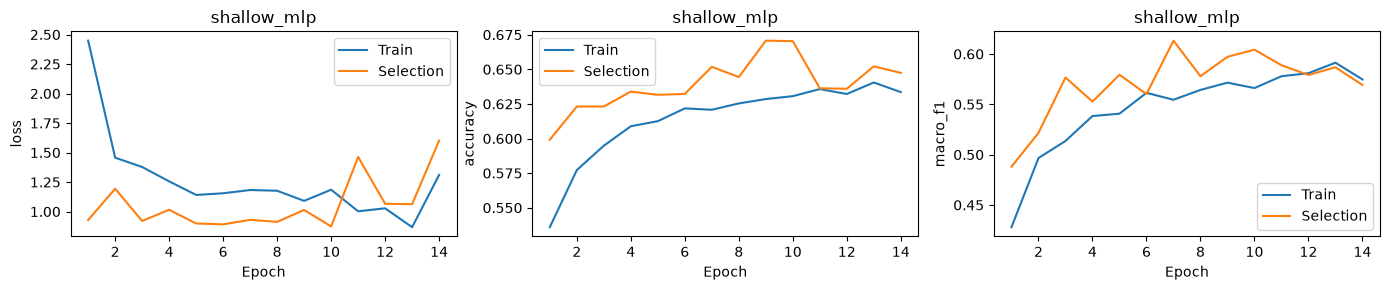

In [31]:
loader = loaders['season']['selection']
for method in ['shallow_mlp']:
    model = models['season'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('season', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['season'])), target_names=labels_by_target['season'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('season')}_{method}_selection_per_class.csv")
    history = histories['season'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('season')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.1.5. Evaluation Analysis

**Complete after execution:** Use these scores as the baseline. Identify frequent and rare labels with weak recall and describe the training/selection gap. Support each claim with the displayed metrics and curves. Do not assume that a larger model performs better.

### 5.2. Deeper MLP


The deeper MLP processes the same flattened RGB input through three hidden layers. ReLU activations allow successive nonlinear transformations, while dropout reduces reliance on individual activations. Compare its validation metrics and learning-curve gap with the shallow baseline before concluding that depth is useful.


#### 5.2.1. Model Architecture

Flatten the image and use three hidden layers to test whether additional nonlinear transformations improve generalization. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.

In [32]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256, 128, 64]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['season'])), ModelMetadata(name='metadata')])
models['season']['deeper_mlp'] = keras.Sequential(layers, name='deeper_mlp')
models['season']['deeper_mlp'].summary()

Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,478,852 (36.16 MB)

 Trainable params: 9,478,852 (36.16 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.

In [33]:
model = models['season']['deeper_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['season']))])

#### 5.2.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.

In [34]:
loaders['season']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['season']['deeper_mlp'].fit(loaders['season']['train'], validation_data=loaders['season']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['season']['deeper_mlp'] = pd.DataFrame(fitted.history)
display(histories['season']['deeper_mlp'].tail())

Epoch 1/30
423/423 - 12s - 28ms/step - accuracy: 0.4724 - loss: 1.5972 - macro_f1: 0.3534 - val_accuracy: 0.5823 - val_loss: 0.9516 - val_macro_f1: 0.4563
Epoch 2/30
423/423 - 11s - 26ms/step - accuracy: 0.5560 - loss: 0.9992 - macro_f1: 0.4361 - val_accuracy: 0.6157 - val_loss: 0.8527 - val_macro_f1: 0.5171
Epoch 3/30
423/423 - 11s - 26ms/step - accuracy: 0.5745 - loss: 0.9474 - macro_f1: 0.4753 - val_accuracy: 0.6285 - val_loss: 0.8430 - val_macro_f1: 0.5409
Epoch 4/30
423/423 - 11s - 26ms/step - accuracy: 0.5898 - loss: 0.9245 - macro_f1: 0.5041 - val_accuracy: 0.6211 - val_loss: 0.8529 - val_macro_f1: 0.5235
Epoch 5/30
423/423 - 11s - 25ms/step - accuracy: 0.6039 - loss: 0.8954 - macro_f1: 0.5313 - val_accuracy: 0.6572 - val_loss: 0.8121 - val_macro_f1: 0.5926
Epoch 6/30
423/423 - 11s - 27ms/step - accuracy: 0.6132 - loss: 0.8788 - macro_f1: 0.5442 - val_accuracy: 0.6339 - val_loss: 0.8555 - val_macro_f1: 0.5635
Epoch 7/30
423/423 - 11s - 27ms/step - accuracy: 0.6202 - loss: 0.8699

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
13,0.646941,0.827773,0.594756,0.660256,0.818511,0.587337
14,0.647644,0.826402,0.594723,0.671053,0.777619,0.631403
15,0.651491,0.816050,0.606311,0.667004,0.784464,0.613970
16,0.656040,0.807596,0.613246,0.667004,0.774040,0.628397
17,0.660330,0.805918,0.615997,0.667004,0.795142,0.615131


#### 5.2.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.

season deeper_mlp


selection_accuracy    0.667679
selection_macro_f1    0.631818
dtype: float64

,precision,recall,f1-score,support
Fall,0.621881,0.407035,0.492027,796.000000
Spring,0.818182,0.469565,0.596685,115.000000
Summer,0.643702,0.831341,0.725587,1506.000000
Winter,0.807870,0.638026,0.712972,547.000000
accuracy,0.667679,0.667679,0.667679,0.667679
macro avg,0.722909,0.586492,0.631818,2964.000000
weighted avg,0.674908,0.667679,0.655534,2964.000000


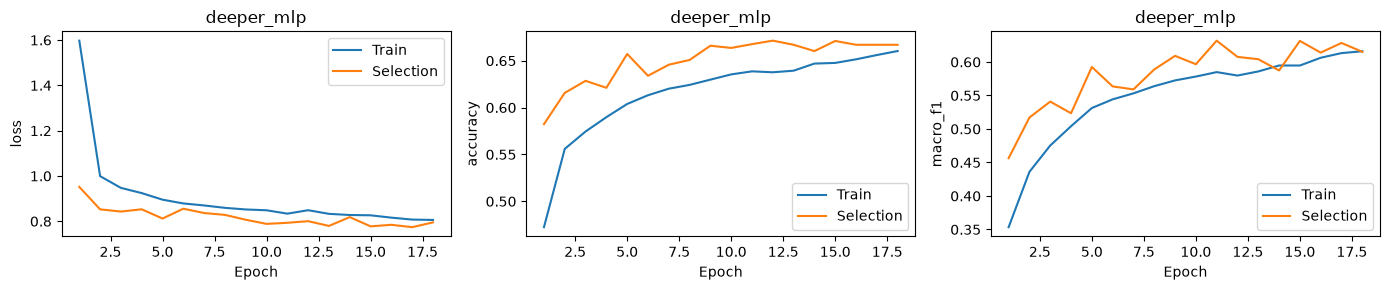

In [35]:
loader = loaders['season']['selection']
for method in ['deeper_mlp']:
    model = models['season'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('season', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['season'])), target_names=labels_by_target['season'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('season')}_{method}_selection_per_class.csv")
    history = histories['season'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('season')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.2.5. Evaluation Analysis

**Complete after execution:** Compare against the shallow MLP using the same selection images. Explain whether extra depth improves macro-F1 or mainly improves training fit. Support each claim with the displayed metrics and curves. Do not assume that a larger model performs better.

### 5.3. Convolutional Neural Network (CNN)


The CNN learns local patterns through convolutions and progressively reduces spatial resolution through pooling. Three-block and four-block variants test model capacity, while the scheduled three-block variant isolates the effect of learning-rate reduction. All three remain one CNN family in the main comparison table.


#### 5.3.1. Model Architecture

Convolutions learn local spatial patterns, unlike the flattened MLP inputs. Compare three blocks, the same architecture with a learning-rate schedule, and a four-block variant. Batch normalization stabilizes activations; pooling reduces spatial size. All variants end with a 2 ? 2 pooled grid and a dense head.

In [36]:
CNN_CONFIGS = {'cnn_ordinary': ((32, 64, 128), 128, False), 'cnn_scheduled': ((32, 64, 128), 128, True), 'cnn_four_blocks_scheduled': ((32, 64, 128, 256), 256, True)}
for method, (channels, hidden, scheduled) in CNN_CONFIGS.items():
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal')]
    for width in channels:
        layers.extend([keras.layers.Conv2D(width, 3, padding='same'), keras.layers.BatchNormalization(), keras.layers.Activation('relu'), keras.layers.MaxPooling2D(2)])
    h, w = (IMAGE_SIZE[1] // 2 ** len(channels), IMAGE_SIZE[0] // 2 ** len(channels))
    layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten(), keras.layers.Dense(hidden, activation='relu'), keras.layers.Dropout(0.2), keras.layers.Dense(len(labels_by_target['season'])), ModelMetadata(name='metadata')])
    models['season'][method] = keras.Sequential(layers, name=method)
    models['season'][method].summary()

Model: "cnn_ordinary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,324 (626.27 KB)

 Trainable params: 159,876 (624.52 KB)

 Non-trainable params: 448 (1.75 KB)

...

Model: "cnn_four_blocks_scheduled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_6 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 653,764 (2.49 MB)

 Trainable params: 652,804 (2.49 MB)

 Non-trainable params: 960 (3.75 KB)

#### 5.3.2. Compile the CNN Models

Keep optimizer, loss and metrics the same as the MLPs so the comparison tests architecture and the declared schedule.

In [37]:
for method in CNN_CONFIGS:
    models['season'][method].compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['season']))])

#### 5.3.3. Train and Tune the CNN Models

Scheduled variants halve the learning rate after two epochs without improvement. All variants stop after seven stale epochs. Selection data controls these decisions; test data is not read here.

#### 5.3.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.

season cnn_ordinary


selection_accuracy    0.679487
selection_macro_f1    0.643583
dtype: float64

,precision,recall,f1-score,support
Fall,0.748130,0.376884,0.501253,796.000000
Spring,0.982456,0.486957,0.651163,115.000000
Summer,0.656298,0.854582,0.742429,1506.000000
Winter,0.680734,0.678245,0.679487,547.000000
accuracy,0.679487,0.679487,0.679487,0.679487
macro avg,0.766904,0.599167,0.643583,2964.000000
weighted avg,0.698124,0.679487,0.662503,2964.000000


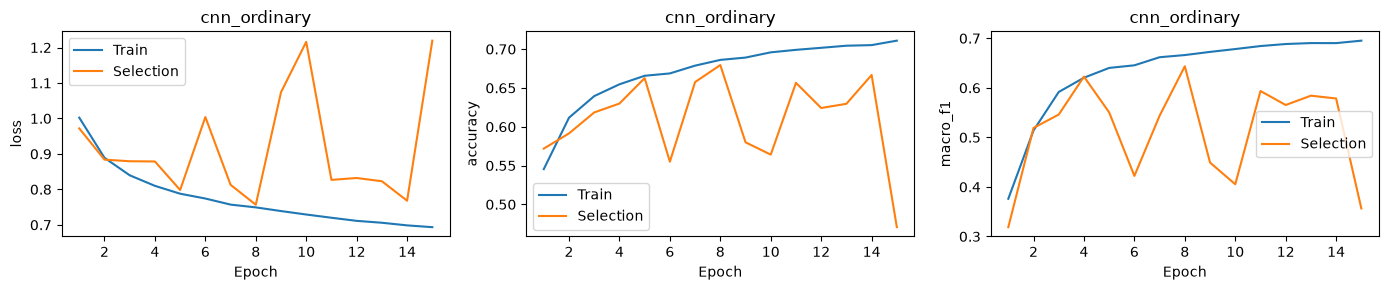

season cnn_scheduled


selection_accuracy    0.695344
selection_macro_f1    0.688180
dtype: float64

,precision,recall,f1-score,support
Fall,0.606318,0.626884,0.616430,796.000000
Spring,0.984127,0.539130,0.696629,115.000000
Summer,0.695158,0.772244,0.731677,1506.000000
Winter,0.832099,0.616088,0.707983,547.000000
accuracy,0.695344,0.695344,0.695344,0.695344
macro avg,0.779426,0.638587,0.688180,2964.000000
weighted avg,0.707784,0.695344,0.694994,2964.000000


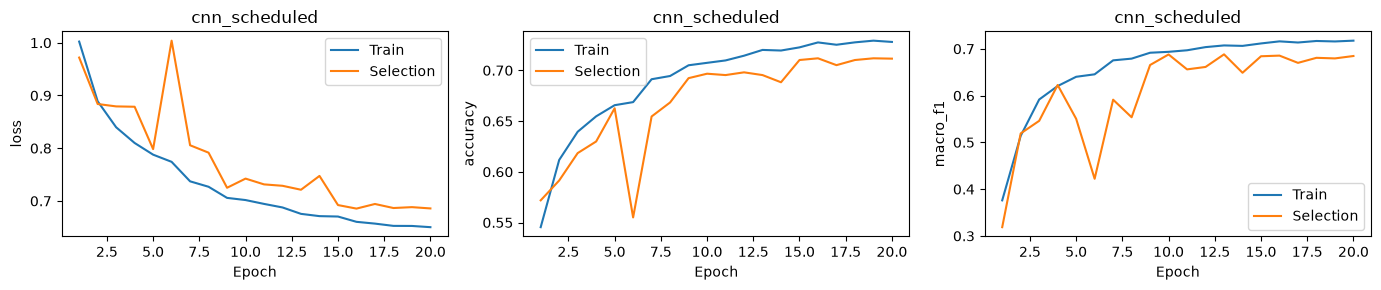

season cnn_four_blocks_scheduled


selection_accuracy    0.754723
selection_macro_f1    0.736312
dtype: float64

,precision,recall,f1-score,support
Fall,0.737681,0.639447,0.685061,796.000000
Spring,0.931507,0.591304,0.723404,115.000000
Summer,0.737658,0.853254,0.791256,1506.000000
Winter,0.816993,0.685558,0.745527,547.000000
accuracy,0.754723,0.754723,0.754723,0.754723
macro avg,0.805960,0.692391,0.736312,2964.000000
weighted avg,0.759826,0.754723,0.751665,2964.000000


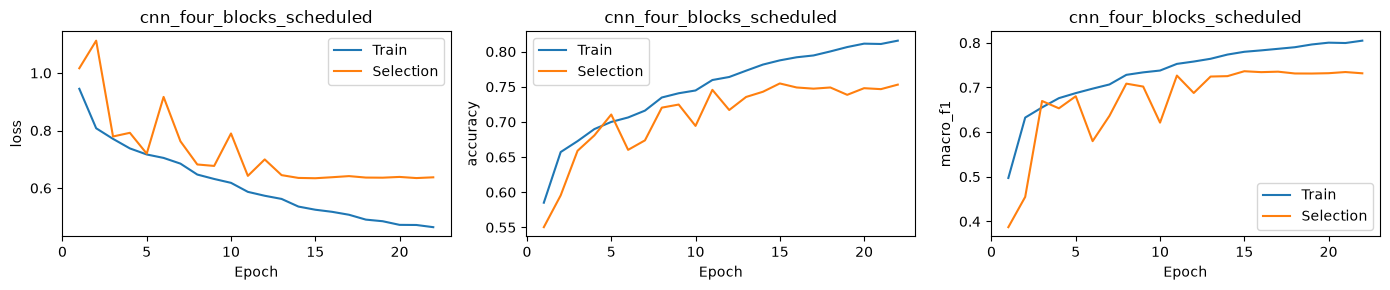

In [39]:
loader = loaders['season']['selection']
for method in list(CNN_CONFIGS):
    model = models['season'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('season', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['season'])), target_names=labels_by_target['season'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('season')}_{method}_selection_per_class.csv")
    history = histories['season'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('season')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.3.5. Evaluation Analysis

**Complete after execution:** Compare the three CNN variants to isolate the schedule effect and the additional block. Discuss category confusions and whether spatial features improve on both MLPs. Support each claim with the displayed metrics and curves. Do not assume that a larger model performs better.

### 5.4. Model Comparison

Use restored best-epoch weights. Choose by macro-F1, then accuracy, then fewer parameters. The final table has three families; the CNN row is its strongest configuration.

In [40]:
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(f1_score(
        truth, predictions, labels=np.unique(truth), average="macro", zero_division=0
    ))

def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += selected.sum() / total * abs(
                float(correct[selected].mean()) - float(confidence[selected].mean())
            )
    return float(error)

def ranked(table):
    """Predeclared: macro F1, then accuracy, then fewer parameters."""
    return table.sort_values(['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
                             ascending=[False, False, True], kind='stable')

In [41]:
comparisons, tuning, winners, checkpoints = ({}, {}, {}, {})
rows = []
loader = loaders['season']['selection']
for method, model in models['season'].items():
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    rows.append(dict(method=method, validation_accuracy=accuracy_score(loader.targets, probabilities.argmax(1)), validation_macro_f1=supported_macro_f1(loader.targets, probabilities.argmax(1)), validation_ece=expected_calibration_error(loader.targets, probabilities), complexity_parameters=model.count_params(), epochs_run=len(histories['season'][method])))
experiments = pd.DataFrame(rows).set_index('method')
experiments.to_csv(RESULTS / f"{stem_for('season')}_experiments.csv")
tuning['season'] = experiments.loc[list(CNN_CONFIGS)].copy()
for metric in ['accuracy', 'macro_f1']:
    tuning['season'][f'{metric}_change_vs_ordinary'] = tuning['season'][f'validation_{metric}'] - tuning['season'].loc['cnn_ordinary', f'validation_{metric}']
best_cnn = ranked(tuning['season']).index[0]
table = experiments.loc[['shallow_mlp', 'deeper_mlp', best_cnn]].copy()
table['family'] = ['shallow_mlp', 'deeper_mlp', 'cnn']
winners['season'] = ranked(table).index[0]
table['selected'] = table.index == winners['season']
comparisons['season'] = table
table.to_csv(RESULTS / f"{stem_for('season')}_comparison.csv")
tuning['season'].to_csv(RESULTS / f"{stem_for('season')}_cnn_tuning.csv")
display(table)
display(tuning['season'])

,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,family,selected
method,,,,,,,
shallow_mlp,0.651822,0.613232,0.048745,9438468,14,shallow_mlp,False
deeper_mlp,0.667679,0.631818,0.054541,9478852,18,deeper_mlp,False
cnn_four_blocks_scheduled,0.754723,0.736312,0.030957,653764,22,cnn,True


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary
method,,,,,,,
cnn_ordinary,0.679487,0.643583,0.030908,160324,15,0.000000,0.000000
cnn_scheduled,0.695344,0.688180,0.020233,160324,20,0.015857,0.044597
cnn_four_blocks_scheduled,0.754723,0.736312,0.030957,653764,22,0.075236,0.092729


### 5.5. Learning Curves

Loss shows optimization progress; the training/selection accuracy gap indicates generalization. Compare validation macro-F1 as well because accuracy is dominated by common labels. Histories are saved for the report.

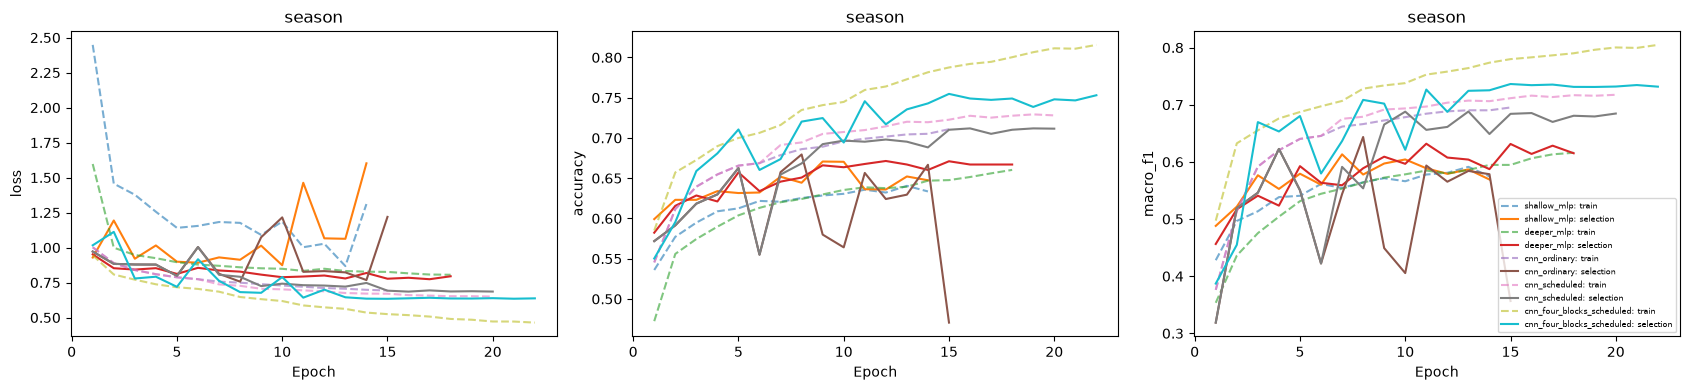

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for method, history in histories['season'].items():
    history = history.copy()
    history.insert(0, 'epoch', np.arange(1, len(history) + 1))
    history.to_csv(RESULTS / f"{stem_for('season')}_{method}_history.csv", index=False)
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.epoch, history[metric], linestyle='--', alpha=0.6, label=f'{method}: train')
        ax.plot(history.epoch, history[f'val_{metric}'], label=f'{method}: selection')
        ax.set(xlabel='Epoch', ylabel=metric, title='season')
axes[-1].legend(fontsize=6)
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('season')}_learning_curves.png", dpi=160)
plt.show()

### 5.6. Model Evaluation & Error Analysis

The following small inference helpers reproduce application preprocessing. Temperature scaling changes confidence, not the predicted class. Calibration is fitted on separate groups, then accepted only if policy-group NLL improves without worsening ECE.

#### 5.6.1. Prepare one inference image

Use the same RGB resizing and training-only normalization as the training batches.

In [43]:
def image_batch(image, image_size, mean, std):
    resized = image.convert("RGB").resize(tuple(image_size), Image.Resampling.BILINEAR)
    array = np.asarray(resized, dtype=np.float32) / 255.0
    array = (array - np.asarray(mean, dtype=np.float32)) / np.asarray(std, dtype=np.float32)
    return array[None, ...]

#### 5.6.2. Rescale confidence

Divide log probabilities by a positive temperature and renormalize.

In [44]:
def temperature_scale(probabilities, temperature=1.0):
    """Rescale confidence without changing the highest-probability class."""
    if not np.isfinite(temperature) or temperature <= 0:
        raise ValueError('Temperature must be finite and positive')
    values = np.asarray(probabilities, dtype=np.float64)
    if temperature == 1.0:
        return values
    logits = np.log(np.clip(values, np.finfo(np.float64).tiny, 1.0)) / temperature
    logits -= logits.max(axis=-1, keepdims=True)
    scaled = np.exp(logits)
    return scaled / scaled.sum(axis=-1, keepdims=True)

#### 5.6.3. Notebook prediction interface

Use the same logits, labels and review-policy semantics as the web application. This class performs inference only.

In [45]:
class FashionClassifier:
    def __init__(self, checkpoint_path, device=None):
        checkpoint = checkpoint_path if isinstance(checkpoint_path, dict) else load_checkpoint(checkpoint_path)
        self.device = "/CPU:0" if device == "cpu" else (device if device and str(device).startswith("/") else None)
        self.target, self.labels = checkpoint["target"], list(checkpoint["labels"])
        self.temperature = float(checkpoint.get("temperature", 1.0))
        self.review_policy = checkpoint.get("review_policy")
        self.model_type = checkpoint["model_type"]
        self.model = checkpoint.get("model")
        self.members = None
        if self.model is not None:
            self.mean, self.std = checkpoint["mean"], checkpoint["std"]
            self.image_size = checkpoint["image_size"]
            self.estimator = self.feature_config = None
        else:
            raise ValueError("Classifier has no trained Keras model")

    def predict_batch(self, inputs):
        with tf.device(self.device):
            probabilities = tf.nn.softmax(self.model(inputs, training=False), axis=-1).numpy()
        return temperature_scale(probabilities, self.temperature)

    def predict_probabilities(self, image):
        inputs = image_batch(image, self.image_size, self.mean, self.std)
        return self.predict_batch(inputs)[0]

    def predict(self, image: Image.Image, top_k: int = 3) -> dict:
        if top_k < 1:
            raise ValueError("top_k must be positive")
        probabilities = self.predict_probabilities(image)
        count = min(top_k, len(self.labels))
        indices = np.argsort(probabilities)[::-1][:count]
        ranked = [
            {"label": self.labels[int(index)], "confidence": float(probabilities[index])}
            for index in indices
        ]
        result = {
            "target": self.target,
            "label": ranked[0]["label"],
            "confidence": ranked[0]["confidence"],
            "top_k": ranked,
        }
        if self.review_policy is not None:
            threshold = self.review_policy['threshold']
            result['needs_review'] = threshold is None or ranked[0]['confidence'] < threshold
            result['review_threshold'] = threshold
            result['confidence_calibrated'] = self.temperature != 1.0
            if self.review_policy.get('brightness_stability') and not result['needs_review']:
                stable_label = int(indices[0])
                unstable = any(
                    int(self.predict_probabilities(ImageEnhance.Brightness(image.convert('RGB')).enhance(factor)).argmax()) != stable_label
                    for factor in (0.8, 1.2)
                )
                if unstable:
                    result['needs_review'] = True
                    result['review_reason'] = 'Prediction changes with lighting'
        return result

#### 5.6.4. Evaluate a partition

Compute accuracy, macro-F1, calibration error, NLL and Brier score. Check that batched and single-image predictions agree.

In [46]:
def evaluate_saved_checkpoint(checkpoint_path, frame, device="cpu", batch_size=64):
    """Re-evaluate a frozen artifact with the application's exact preprocessing.

    This never fits a model or changes its checkpoint. Batching changes only
    execution and may slightly affect floating-point scores; label ordering
    and saved temperature match the web API.
    """
    from sklearn.metrics import log_loss

    if frame.empty:
        raise ValueError("Evaluation requires at least one image")
    predictor = FashionClassifier(checkpoint_path, device=device)
    labels = predictor.labels
    truth = np.asarray([labels.index(label) for label in frame[predictor.target]])
    batches = []
    for start in range(0, len(frame), batch_size):
        inputs = []
        for path in frame.image_path.iloc[start:start + batch_size]:
            with Image.open(path) as source:
                inputs.append(image_batch(source, predictor.image_size, predictor.mean, predictor.std))
        batches.append(predictor.predict_batch(np.concatenate(inputs)))
    probabilities = np.vstack(batches)
    if (probabilities.shape != (len(frame), len(labels))
            or not np.isfinite(probabilities).all()
            or (probabilities < 0).any()
            or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5, rtol=1e-5)):
        raise ValueError("Batch inference returned invalid probabilities")
    predictions = probabilities.argmax(1)
    metrics = {
        "accuracy": float(accuracy_score(truth, predictions)),
        "macro_f1": supported_macro_f1(truth, predictions),
        "ece": expected_calibration_error(truth, probabilities),
        "nll": float(log_loss(truth, probabilities, labels=np.arange(len(labels)))),
        "brier": float(np.mean(np.sum((probabilities - np.eye(len(labels))[truth]) ** 2, axis=1))),
    }
    # Batch and single-image GPU kernels can produce slightly different scores.
    # Sample this difference as a diagnostic, not a requirement for calibration.
    # A 0.001 absolute difference means 0.1 percentage points of probability;
    # it is a warning threshold, not a guarantee of equivalent predictions.
    import warnings

    positions = sorted({0, len(frame) // 2, len(frame) - 1})
    max_absolute_difference = 0.0
    prediction_mismatches = []
    for position in positions:
        with Image.open(frame.image_path.iloc[position]) as source:
            single = np.asarray(predictor.predict_probabilities(source))
        if (single.shape != probabilities[position].shape
                or not np.isfinite(single).all()
                or (single < 0).any()
                or not np.isclose(single.sum(), 1.0, atol=1e-5, rtol=1e-5)):
            raise ValueError("Single-image inference returned invalid probabilities")
        difference = float(np.max(np.abs(probabilities[position] - single)))
        max_absolute_difference = max(max_absolute_difference, difference)
        if predictions[position] != single.argmax():
            prediction_mismatches.append(position)
    inference_consistency = {
        "sample_count": len(positions),
        "max_absolute_difference": max_absolute_difference,
        "prediction_mismatch_positions": prediction_mismatches,
    }
    if max_absolute_difference > 1e-3 or prediction_mismatches:
        warnings.warn(
            f"Batch/single-image inference diagnostic: {inference_consistency}. "
            "Evaluation and calibration use batched probabilities. Inspect these "
            "differences before interpreting single-image application results.",
            RuntimeWarning, stacklevel=2,
        )
    return {"labels": labels, "truth": truth, "predictions": predictions,
            "probabilities": probabilities, "metrics": metrics,
            "inference_consistency": inference_consistency}

#### 5.6.5. Fit temperature and the review threshold

Search temperature on calibration groups, then use policy groups to decide whether to keep it and when to request manual review.

In [47]:
def calibrate(checkpoint, calibration, policy, device):
    checkpoint = dict(checkpoint)
    cal = evaluate_saved_checkpoint(checkpoint, calibration, device=str(device))
    raw = evaluate_saved_checkpoint(checkpoint, policy, device=str(device))
    fit = minimize_scalar(lambda log_t: log_loss(
        cal['truth'], temperature_scale(cal['probabilities'], np.exp(log_t)),
        labels=np.arange(len(checkpoint['labels']))),
        bounds=(np.log(0.25), np.log(10)), method='bounded')
    temperature = float(np.exp(fit.x))
    scaled = temperature_scale(raw['probabilities'], temperature)
    if (log_loss(raw['truth'], scaled, labels=np.arange(len(checkpoint['labels']))) < raw['metrics']['nll']
            and expected_calibration_error(raw['truth'], scaled) <= raw['metrics']['ece']):
        checkpoint['temperature'] = temperature
    else:
        scaled = raw['probabilities']
    threshold = None
    for value in np.round(np.arange(0.50, 1.00, 0.01), 2):
        accepted = scaled.max(1) >= value
        if accepted.sum() >= 100 and np.mean(scaled.argmax(1)[accepted] == raw['truth'][accepted]) >= 0.90:
            threshold = float(value)
            break
    checkpoint['review_policy'] = {'threshold': threshold, 'target_accuracy': 0.90,
                                   'minimum_policy_samples': 100,
                                   'brightness_stability': checkpoint['target'] == 'articleType'}
    return checkpoint

In [48]:
method = winners['season']
checkpoints['season'] = dict(target='season', labels=labels_by_target['season'], model=models['season'][method], model_type=method, temperature=1.0, mean=normalisation['mean'], std=normalisation['std'], image_size=list(IMAGE_SIZE), comparison_row=comparisons['season'].loc[method].to_dict())
checkpoints['season'] = calibrate(checkpoints['season'], frames['season']['calibration'], frames['season']['policy'], DEVICE)

/home/khoile/.venvs/fashion-keras/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/home/khoile/.venvs/fashion-keras/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/tmp/ipykernel_58202/4048643374.py:4: RuntimeWarning: Batch/single-image inference diagnostic: {'sample_count': 3, 'max_absolute_difference': 0.0013695359230041504, 'prediction_mismatch_positions': []}. Evaluation and calibration use batched probabilities. Inspect these differences before interpreting single-image application results.
  raw = evaluate_saved_checkpoint(checkpoint, policy, device=str(device))


#### 5.6.6. Evaluate the selected model on the internal test

Do not revise the architecture based on this table. Report prior development exposure and inspect per-class support before interpreting overall accuracy.

In [49]:
test_results = {}
result = evaluate_saved_checkpoint(checkpoints['season'], task_frame('season', 'test'), device=DEVICE)
test_results['season'] = result
checkpoints['season']['test_metrics'] = result['metrics']
display(pd.Series(result['metrics'], name='season'))
report = classification_report(result['truth'], result['predictions'], labels=np.arange(len(result['labels'])), target_names=result['labels'], output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RESULTS / f"{stem_for('season')}_test_per_class.csv")
pd.Series(result['metrics']).to_csv(RESULTS / f"{stem_for('season')}_test_metrics.csv")

/home/khoile/.venvs/fashion-keras/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


accuracy    0.731584
macro_f1    0.714990
ece         0.048662
nll         0.657822
brier       0.361788
Name: season, dtype: float64

,precision,recall,f1-score,support
Fall,0.699786,0.631206,0.663729,1551.000000
Spring,0.966443,0.580645,0.725441,248.000000
Summer,0.715385,0.843979,0.774380,2865.000000
Winter,0.813215,0.608944,0.696409,1051.000000
accuracy,0.731584,0.731584,0.731584,0.731584
macro avg,0.798707,0.666193,0.714990,5715.000000
weighted avg,0.740037,0.731584,0.727887,5715.000000


#### 5.6.7. Confidence bins

Compare average confidence with actual accuracy within each bin. Low-support bins are less reliable.

In [50]:
def calibration_table(truth: np.ndarray, probabilities: np.ndarray) -> pd.DataFrame:
    """Return a ten-bin reliability table for notebook evidence."""
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == np.asarray(truth)
    frame = pd.DataFrame({"confidence": confidence, "correct": correct})
    frame["bin"] = pd.cut(
        frame.confidence, bins=np.linspace(0, 1, 11), include_lowest=True
    )
    return frame.groupby("bin", observed=False).agg(
        mean_confidence=("confidence", "mean"),
        accuracy=("correct", "mean"),
        samples=("correct", "size"),
    )

In [51]:
result = test_results['season']
display(calibration_table(result['truth'], result['probabilities']))

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",NaN,NaN,0
"(0.3, 0.4]",0.376551,0.371795,78
"(0.4, 0.5]",0.459211,0.418919,444
"(0.5, 0.6]",0.548502,0.489144,783
"(0.6, 0.7]",0.650001,0.592541,724
"(0.7, 0.8]",0.747063,0.672811,651
"(0.8, 0.9]",0.853215,0.783493,836


#### 5.6.8. Confusion matrices

Rows are true labels and columns are predicted labels. The article-type plot groups uncommon predicted classes into an Other column for readability.

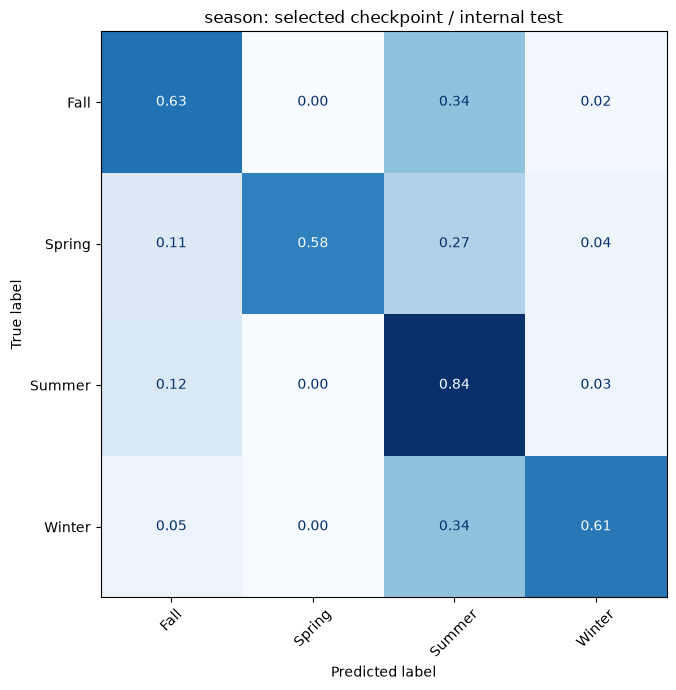

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
directory = RESULTS
stem = stem_for('season')
result = test_results['season']
labels = result['labels']
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(result['truth'], result['predictions'], labels=np.arange(len(labels)), display_labels=labels, normalize='true', values_format='.2f', xticks_rotation=45, ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"{'season'}: selected checkpoint / internal test")
fig.tight_layout()
fig.savefig(FIGURES / f'{stem}_confusion.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Ultimate Judgement

Choose the model using the declared selection rule, then justify the decision using generalization, class-wise errors and confidence reliability. Internal-test scores describe the selected model; they do not change the selection.

In [53]:
winner = comparisons['season'].loc[winners['season']]
baseline = comparisons['season'].loc['shallow_mlp']
display(pd.Series({'selected_method': winners['season'], 'selection_macro_f1': winner.validation_macro_f1, 'selection_accuracy': winner.validation_accuracy, 'macro_f1_gain_over_baseline': winner.validation_macro_f1 - baseline.validation_macro_f1, 'internal_test_accuracy': test_results['season']['metrics']['accuracy'], 'internal_test_macro_f1': test_results['season']['metrics']['macro_f1']}, name='season'))

selected_method                cnn_four_blocks_scheduled
selection_macro_f1                              0.736312
selection_accuracy                              0.754723
macro_f1_gain_over_baseline                      0.12308
internal_test_accuracy                          0.731584
internal_test_macro_f1                           0.71499
Name: season, dtype: object

### 6.1. Decision Analysis

**Complete after execution:** Explain the measured benefit over the baseline, remaining failure cases, calibration reliability and practical limitations. State whether the evidence supports use in the application and acknowledge prior internal-test exposure.

### 6.2. Independent Literature Comparison

Utkarsh Mall, Kevin Matzen, Bharath Hariharan, Noah Snavely and Kavita Bala (2019). [GeoStyle: Discovering Fashion Trends and Events](https://arxiv.org/abs/1908.11412). *ICCV*. [Authors' project and code](https://geostyle.cs.cornell.edu/).

GeoStyle studies temporal clothing trends using 7.7 million street/social-media images from 44 cities. It aggregates calibrated clothing-attribute predictions into weekly trends and models seasonal variation and events. Its attribute pipeline uses GoogLeNet, with ImageNet-pretrained weights available in the authors' implementation. Our task instead predicts one of four catalogue-season labels from a single product image, using a plain CNN trained from scratch. GeoStyle's temporal forecasting evaluation differs from our fixed product-group train/validation/test split, and forecast errors cannot be ranked against our macro F1. It supplies a useful conceptual comparison: real seasonal patterns involve time and geography that our classifier does not observe. It does not validate our catalogue labels as weather suitability or prove that our model uses seasonal visual cues. No external images or pretrained weights were used here.

Historical numerical comparisons in this literature discussion are not results of the new MLP/CNN experiment; use the executed tables above.

## 7. Final Prediction

Save the selected model, reload it, and predict a sample image. Exported metadata allows the standalone prediction scripts and web application to apply the same preprocessing and confidence policy.

In [54]:
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata
    model.save(path)
    return path

In [55]:
stem, method = (stem_for('season'), winners['season'])
path = save_checkpoint(checkpoints['season'], OUTPUT / f'{stem}_model.keras')
histories['season'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(target='season', selected=method, cnn_selected=ranked(tuning['season']).index[0], framework='tensorflow_keras', model_file=path.name, test_metrics=test_results['season']['metrics'], split_sizes={name: len(frame) for name, frame in frames['season'].items()}, test_scope='internal_test_with_prior_development_exposure')
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)

Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models/season_model.keras


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.

In [56]:
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(f"Missing trained classifier: {path}. Run the classification notebook first.")

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")

In [57]:
predictor = FashionClassifier(OUTPUT / f"{stem_for('season')}_model.keras")
with Image.open(frames['season']['selection'].image_path.iloc[0]) as image:
    print(predictor.predict(image))

{'target': 'season', 'label': 'Summer', 'confidence': 0.72528076171875, 'top_k': [{'label': 'Summer', 'confidence': 0.72528076171875}, {'label': 'Fall', 'confidence': 0.24996794760227203}, {'label': 'Spring', 'confidence': 0.015398730523884296}], 'needs_review': True, 'review_threshold': 0.77, 'confidence_calibrated': False}


## 8. Conclusion

**Complete after execution:** Summarize the task, the three model families compared, the selected method and the strongest measured evidence supporting it. State important error patterns and data limitations, then identify a concrete improvement motivated by those findings. Keep this conclusion consistent with the exported model and avoid unmeasured performance claims.